## Langkah 0 — Import Library dan Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset iris
df = sns.load_dataset('iris')


## Langkah 1 — Load & Inspect Dataset

Tahap ini dilakukan untuk melihat struktur dataset, tipe data, dan statistik awal dari dataset Iris.


In [2]:
print('Shape Dataset:', df.shape)


Shape Dataset: (150, 5)


In [3]:
print(df.dtypes)


sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [4]:
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.describe().round(3)


### Interpretasi

Dataset Iris memiliki 150 baris dan 5 kolom. Empat kolom bertipe numerik dan satu kolom kategorikal yaitu species. Dataset sudah siap digunakan untuk analisis statistik.


## Langkah 2 — Statistik Deskriptif Lengkap

Pada tahap ini dilakukan perhitungan mean, median, standar deviasi, varians, skewness, dan kurtosis pada setiap kolom numerik.


In [5]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]

    print(f'\n=== {col_name} ===')
    print(f'Mean      : {col.mean():.3f}')
    print(f'Median    : {col.median():.3f}')
    print(f'Std Dev   : {col.std():.3f}')
    print(f'Variance  : {col.var():.3f}')
    print(f'Skewness  : {col.skew():.3f}')
    print(f'Kurtosis  : {col.kurt():.3f}')



=== sepal_length ===
Mean      : 5.843
Median    : 5.800
Std Dev   : 0.828
Variance  : 0.686
Skewness  : 0.315
Kurtosis  : -0.552

=== sepal_width ===
Mean      : 3.057
Median    : 3.000
Std Dev   : 0.436
Variance  : 0.190
Skewness  : 0.319
Kurtosis  : 0.228

=== petal_length ===
Mean      : 3.758
Median    : 4.350
Std Dev   : 1.765
Variance  : 3.116
Skewness  : -0.275
Kurtosis  : -1.402

=== petal_width ===
Mean      : 1.199
Median    : 1.300
Std Dev   : 0.762
Variance  : 0.581
Skewness  : -0.103
Kurtosis  : -1.341


### Interpretasi

Nilai mean dan median pada sebagian besar kolom cukup berdekatan sehingga distribusi data relatif seimbang. Nilai skewness menunjukkan adanya sedikit kemencengan distribusi pada beberapa variabel.


## Langkah 3 — Analisis Distribusi (Histogram + KDE)

Visualisasi histogram dan KDE digunakan untuk melihat distribusi data pada variabel sepal_length.


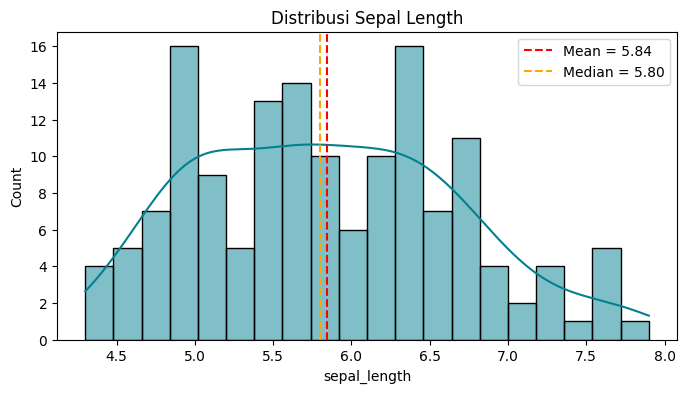

In [6]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    color='#028090',
    bins=20,
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length')
ax.legend()

plt.show()


### Interpretasi

Distribusi sepal_length terlihat mendekati distribusi normal karena bentuk histogram menyerupai kurva lonceng dan posisi mean serta median cukup berdekatan.


## Langkah 4 — Boxplot per Spesies

Boxplot dan violin plot digunakan untuk membandingkan distribusi petal_length pada masing-masing spesies bunga Iris.


/tmp/ipykernel_7159/1780297670.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7159/1780297670.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


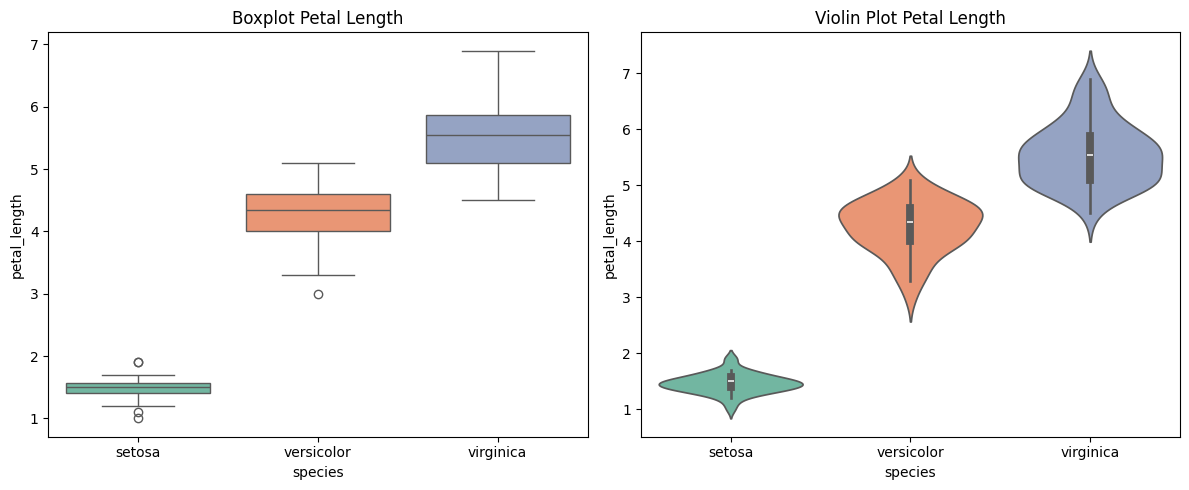

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Boxplot Petal Length')

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()


### Interpretasi

Spesies setosa memiliki nilai petal_length paling kecil. Virginica memiliki nilai paling besar dan distribusi paling lebar. Versicolor berada di antara keduanya.


## Langkah 5 — Matriks Korelasi Pearson

Analisis korelasi Pearson digunakan untuk melihat hubungan antar variabel numerik.


In [8]:
corr = df.drop('species', axis=1).corr(method='pearson')

print(corr.round(3))


              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


In [9]:
mask = np.triu(np.ones(corr.shape, dtype=bool))

corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()

print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')


Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


### Interpretasi

Pasangan variabel dengan korelasi tertinggi adalah petal_length dan petal_width. Hal ini menunjukkan hubungan positif yang sangat kuat.


## Langkah 6 — Scatter Plot dan Heatmap

Scatter plot digunakan untuk melihat hubungan antar dua variabel dengan korelasi tertinggi, sedangkan heatmap digunakan untuk melihat seluruh korelasi variabel.


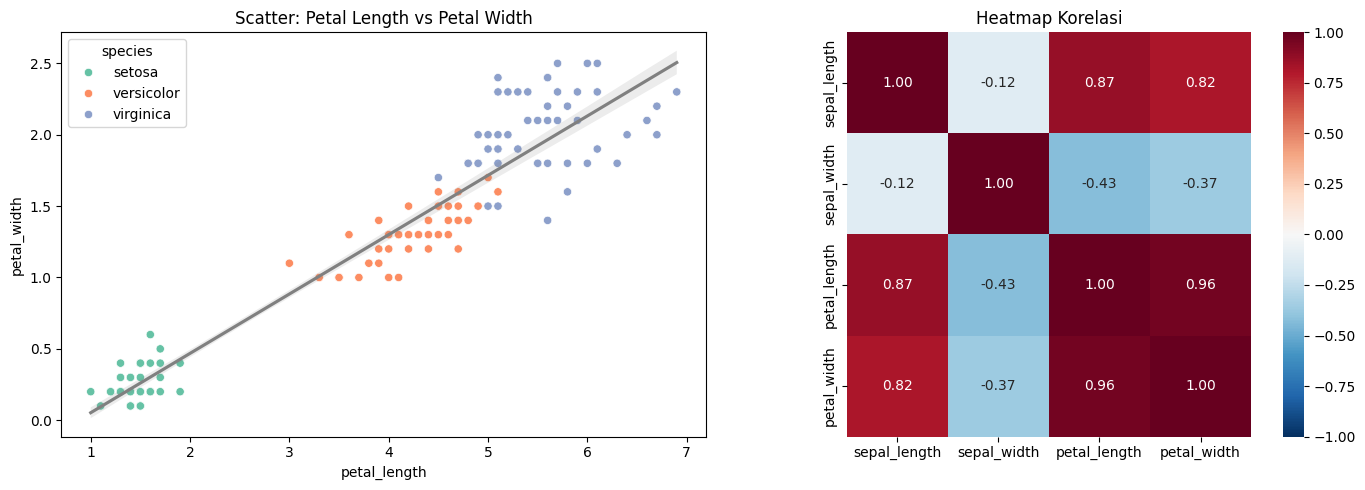

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()


### Interpretasi

Scatter plot menunjukkan hubungan positif yang kuat antara petal_length dan petal_width. Heatmap juga memperlihatkan bahwa sebagian besar variabel memiliki korelasi positif.


# Kesimpulan

Berdasarkan hasil analisis statistik dan visualisasi, dataset Iris memiliki distribusi data yang cukup baik dan hubungan kuat antar beberapa variabel numerik, terutama pada fitur petal_length dan petal_width.
